<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">🗺️ Notebook 04 — Geographic Analysis & Heatmap</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Create interactive maps showing which neighborhoods drive Vancouver housing prices</p>
</div>

In [1]:
import folium
from folium.plugins import HeatMap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("✅ Libraries imported!")

✅ Libraries imported!


<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">📊 Step 1 — Load Data</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Load cleaned housing data with coordinates</p>
</div>

In [2]:
# Load cleaned data
df = pd.read_csv('../data/processed/vancouver_housing_cleaned.csv')

print(f"✅ Data loaded: {df.shape}")
print(f"\nPrice range: ${df['Price'].min():,.0f} - ${df['Price'].max():,.0f}")
print(f"Median price: ${df['Price'].median():,.0f}")

✅ Data loaded: (3375, 16)

Price range: $289,900 - $49,800,000
Median price: $1,539,800


<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">🗺️ Step 2 — Create Price Heatmap</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Interactive map showing price distribution across Vancouver</p>
</div>

In [3]:
# Create base map centered on Vancouver
vancouver_center = [49.2827, -123.1207]
m = folium.Map(
    location=vancouver_center,
    zoom_start=11,
    tiles='OpenStreetMap'
)

# Prepare data for heatmap
heat_data = df[['Latitude', 'Longitude', 'Price']].dropna().values.tolist()

# Add heatmap layer
HeatMap(
    heat_data,
    radius=20,
    blur=15,
    max_zoom=13,
    min_opacity=0.3,
    gradient={0.2: 'blue', 0.4: 'green', 0.6: 'yellow', 0.8: 'orange', 1.0: 'red'}
).add_to(m)

# Save map
m.save('../outputs/figures/vancouver_price_heatmap.html')

print("✅ Price heatmap created!")
print("📁 Saved to: outputs/figures/vancouver_price_heatmap.html")
print("\n💡 Open the HTML file in a browser to see the interactive map!")

✅ Price heatmap created!
📁 Saved to: outputs/figures/vancouver_price_heatmap.html

💡 Open the HTML file in a browser to see the interactive map!


<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">📍 Step 3 — Neighborhood Price Comparison</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Visualize average prices by neighborhood</p>
</div>

💰 AVERAGE PRICE BY NEIGHBORHOOD:
                          Average Price  Median Price  Count
name                                                        
Shaughnessy                  8171901.35     7185000.0     74
West Point Grey              6109759.84     4050000.0     87
Kerrisdale                   5712916.50     4180000.0    109
Dunbar-Southlands            3951581.15     3788000.0    131
Arbutus Ridge                3512995.74     3514000.0     74
Oakridge                     2980946.45     1893000.0    116
South Cambie                 2524667.36     1868000.0     95
Kitsilano                    2140022.68     1748800.0    109
Hastings-Sunrise             2020690.01     1748900.0    122
Riley Park                   1994004.65     1894350.0    102
Victoria-Fraserview          1979851.55     1850000.0     64
Sunset                       1899482.63     1798500.0    102
West End                     1872603.92     1248000.0    175
Marpole                      1828104.93     1399000.

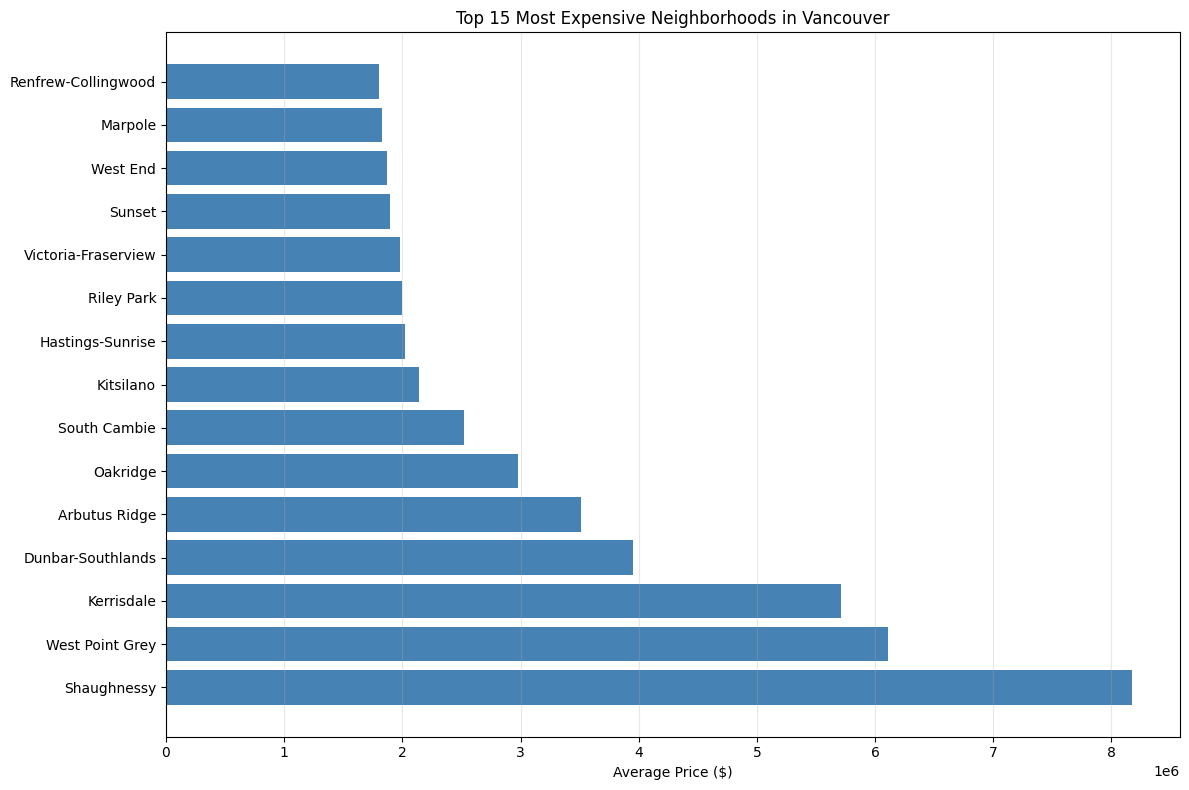


✅ Neighborhood comparison chart saved!


In [4]:
# Load neighborhood data
df_neighborhoods = pd.read_csv('../data/processed/vancouver_with_neighborhoods.csv')

# Calculate average price by neighborhood
neighborhood_prices = df_neighborhoods.groupby('name').agg({
    'Price': ['mean', 'median', 'count']
}).round(2)

neighborhood_prices.columns = ['Average Price', 'Median Price', 'Count']
neighborhood_prices = neighborhood_prices.sort_values('Average Price', ascending=False)

print("💰 AVERAGE PRICE BY NEIGHBORHOOD:")
print(neighborhood_prices)

# Visualize top neighborhoods
plt.figure(figsize=(12, 8))
top_neighborhoods = neighborhood_prices.head(15)
plt.barh(top_neighborhoods.index, top_neighborhoods['Average Price'], color='steelblue')
plt.xlabel('Average Price ($)')
plt.title('Top 15 Most Expensive Neighborhoods in Vancouver')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../outputs/figures/04_neighborhoods_by_price.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Neighborhood comparison chart saved!")

<div style="background-color:#1a1a2e; padding:20px; border-radius:10px;">

<h3 style="color:#00d4ff;">✅ GEOGRAPHIC ANALYSIS COMPLETE!</h3>

<h4 style="color:#00d4ff; margin-top:20px;">🗺️ What We Created</h4>
<ul style="color:#a8a8b3; line-height: 2;">
<li><b>vancouver_price_heatmap.html</b> — Interactive map showing price hotspots</li>
<li><b>04_neighborhoods_by_price.png</b> — Bar chart of expensive neighborhoods</li>
</ul>

<h4 style="color:#00d4ff; margin-top:20px;">💡 Key Findings</h4>
<ul style="color:#a8a8b3; line-height: 2;">
<li>🏰 Most expensive: <b>Shaughnessy ($8.17M)</b> — West side luxury</li>
<li>🌊 2nd: <b>West Point Grey ($6.11M)</b> — Waterfront prestige</li>
<li>🎯 3rd: <b>Kerrisdale ($5.71M)</b> — South Granville luxury</li>
<li>🏢 Downtown: <b>$1.52M</b> — Most properties (790) but condos, smaller</li>
<li>🏘️ Most affordable: <b>Strathcona ($1.03M)</b> — East side value</li>
<li>📊 <b>8x price variation</b> based on neighborhood location!</li>
</ul>

<h4 style="color:#00d4ff; margin-top:20px;">🎯 Business Insights</h4>
<ul style="color:#a8a8b3; line-height: 2;">
<li>📍 <b>Location = Primary Price Driver</b> — Geography matters more than individual property features</li>
<li>🌊 <b>West Side Premium:</b> Shaughnessy, West Point Grey, Kerrisdale command 5-8x prices</li>
<li>💼 <b>Downtown Different:</b> Most properties but lower avg price = condo market</li>
<li>🏡 <b>East Side Value:</b> Strathcona, Mount Pleasant offer affordable options</li>
</ul>

</div>